In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("spotify_data clean.csv") # Please upload 'spotify_data clean.csv' to your Colab environment

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (8582, 15)

Missing values:
 track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

Data types:
 track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
dtype: object


**MISSING VALUE HANDLING**

In [ ]:
# artist_name is a core identifier — only 3 rows affected, safe to drop
df = df.dropna(subset=['artist_name']).copy()

# artist_genres missing in ~39% of rows — too much data to lose by dropping.
# A missing genre on Spotify usually means the artist genuinely has no
# assigned genre tag (common for newer/niche artists), so we encode it
# as its own category rather than guessing a genre.
df['artist_genres'] = df['artist_genres'].fillna('Unknown')

print("Remaining missing values:\n", df.isnull().sum().sum())

Remaining missing values:
 0


**DUPLICATE DETECTION**

In [ ]:
# --- OPTIONAL: inject a few synthetic duplicates to demonstrate detection ---
demo_dupes = df.sample(5, random_state=42)
df_demo = pd.concat([df, demo_dupes], ignore_index=True)

print("Exact duplicate rows (demo):", df_demo.duplicated().sum())
df_demo = df_demo.drop_duplicates()
print("Shape after removing exact duplicates:", df_demo.shape)


# --- Actual dataset: check for exact and near-duplicates ---
print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate track_id:", df['track_id'].duplicated().sum())

near_dupes = df[df.duplicated(subset=['track_name', 'artist_name'], keep=False)]
print("Rows sharing track_name + artist_name:", near_dupes.shape[0])
near_dupes.sort_values(['artist_name', 'track_name']).head(10)

df['is_track_repeat'] = df.duplicated(subset=['track_name', 'artist_name'], keep=False)
print(f"Flagged {df['is_track_repeat'].sum()} rows as repeat releases (kept, not dropped)")

Exact duplicate rows (demo): 5
Shape after removing exact duplicates: (8579, 18)

Exact duplicate rows: 0
Duplicate track_id: 0
Rows sharing track_name + artist_name: 1237
Flagged 1237 rows as repeat releases (kept, not dropped)


**OUTLIER DETECTION AND TREATMENT**

In [ ]:
# --- Duration outliers (IQR method) ---
Q1 = df['track_duration_min'].quantile(0.25)
Q3 = df['track_duration_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

duration_outliers = df[(df['track_duration_min'] < lower_bound) | (df['track_duration_min'] > upper_bound)]
print(f"Duration outliers: {len(duration_outliers)} rows (bounds: {lower_bound:.2f} - {upper_bound:.2f} min)")

# Treatment: cap (winsorize) rather than delete — extreme durations are
# usually real (interludes, extended remixes), not data entry errors
df['track_duration_min_capped'] = df['track_duration_min'].clip(lower=lower_bound, upper=upper_bound)

# --- Zero-follower "popular" artists: likely a data capture gap, not a real outlier ---
zero_followers = df[df['artist_followers'] == 0]
print(f"\nArtists with 0 followers: {len(zero_followers)}")
print(zero_followers[['artist_name', 'track_popularity', 'artist_followers']])

# Treatment: flag rather than impute — imputing a follower count would
# fabricate data; flagging lets downstream analysis exclude/include deliberately
df['followers_missing_flag'] = df['artist_followers'] == 0

Duration outliers: 358 rows (bounds: 1.21 - 5.66 min)

Artists with 0 followers: 5
    artist_name  track_popularity  artist_followers
552  Daya Blaze                 5                 0
582  Daya Blaze                 4                 0
594  Daya Blaze                 5                 0
596  Daya Blaze                 0                 0
618  Daya Blaze                 5                 0


**DATA TYPE CONVERSION**

In [ ]:
# Dates
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

# Categorical types — reduces memory and signals intent clearly
df['album_type'] = df['album_type'].astype('category')
df['explicit'] = df['explicit'].astype(bool)

# Numeric integrity check — force numeric, coerce anything unparseable to NaN
numeric_cols = ['track_number', 'track_popularity', 'artist_popularity',
                 'artist_followers', 'album_total_tracks']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print(df.dtypes)

track_id                             object
track_name                           object
track_number                          Int64
track_popularity                      Int64
explicit                               bool
artist_name                          object
artist_popularity                     Int64
artist_followers                      Int64
artist_genres                        object
album_id                             object
album_name                           object
album_release_date           datetime64[ns]
album_total_tracks                    Int64
album_type                         category
track_duration_min                  float64
is_track_repeat                        bool
track_duration_min_capped           float64
followers_missing_flag              boolean
dtype: object


**FINAL CLEANED OUTPUT**

In [ ]:
print("Final shape:", df.shape)
print("Remaining nulls:\n", df.isnull().sum())
print("\nFlags summary:")
print(f"  Repeat-release rows flagged: {df['is_track_repeat'].sum()}")
print(f"  Zero-follower rows flagged: {df['followers_missing_flag'].sum()}")
print(f"  Duration values capped: {len(duration_outliers)}")

df.to_csv("spotify_data_fully_cleaned.csv", index=False)

Final shape: (8579, 18)
Remaining nulls:
 track_id                     0
track_name                   0
track_number                 0
track_popularity             0
explicit                     0
artist_name                  0
artist_popularity            0
artist_followers             0
artist_genres                0
album_id                     0
album_name                   0
album_release_date           0
album_total_tracks           0
album_type                   0
track_duration_min           0
is_track_repeat              0
track_duration_min_capped    0
followers_missing_flag       0
dtype: int64

Flags summary:
  Repeat-release rows flagged: 1237
  Zero-follower rows flagged: 5
  Duration values capped: 358


**Sentiment Analysis, Feature Selection, Correlation & Hypothesis Testing**

SETUP- LOAD THE CLEANED DATA

In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from scipy import stats
from sklearn.feature_selection import SelectKBest, f_regression

df = pd.read_csv("spotify_data_fully_cleaned.csv")
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

**SENTIMENT ANALYSIS ON TRACK TITLES**

In [ ]:
df['sentiment_polarity'] = df['track_name'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['track_name'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

print(df[['track_name', 'sentiment_polarity', 'sentiment_subjectivity']].head(8))
print("\nPolarity distribution:\n", df['sentiment_polarity'].describe())
print(f"\n% of titles scored as neutral (0.0): {(df['sentiment_polarity']==0).mean()*100:.1f}%")

                                        track_name  sentiment_polarity  \
0                    Trippy Mane (ft. Project Pat)            0.000000   
1                                             OMG!            0.000000   
2                                      Hard 2 Find           -0.291667   
3  Still Get Like That (ft. Project Pat & Starrah)            0.000000   
4                            ride me like a harley            0.000000   
5                                            BLEED            0.000000   
6                             Te Procuro na Cidade            0.000000   
7                                      come closer            0.000000   

   sentiment_subjectivity  
0                0.000000  
1                0.000000  
2                0.541667  
3                0.000000  
4                0.000000  
5                0.000000  
6                0.000000  
7                0.000000  

Polarity distribution:
 count    8579.000000
mean        0.029693
std         0.

In [ ]:
sentiment_bins = pd.cut(df['sentiment_polarity'], bins=[-1.01, -0.01, 0.01, 1.01],
                         labels=['Negative', 'Neutral', 'Positive'])
df['sentiment_label'] = sentiment_bins
print(df['sentiment_label'].value_counts())

sentiment_label
Neutral     6543
Positive    1268
Negative     768
Name: count, dtype: int64


**FEATURE SELECTION**

In [ ]:
candidate_features = ['artist_popularity', 'artist_followers', 'track_duration_min',
                       'track_number', 'album_total_tracks', 'sentiment_polarity']
target = 'track_popularity'

# Filter method 1: correlation with target
corr_with_target = df[candidate_features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print("Correlation with track_popularity:\n", corr_with_target)

# Filter method 2: statistical F-test (SelectKBest)
X = df[candidate_features].fillna(0)
y = df[target]
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'feature': candidate_features,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)
print("\n", feature_scores)

Correlation with track_popularity:
 artist_popularity     0.468081
artist_followers      0.232075
track_duration_min    0.105712
sentiment_polarity    0.014143
track_number         -0.028511
album_total_tracks   -0.053525
Name: track_popularity, dtype: float64

               feature      f_score        p_value
0   artist_popularity  2406.484453   0.000000e+00
1    artist_followers   488.243579  2.856022e-105
2  track_duration_min    96.931170   9.472803e-23
4  album_total_tracks    24.643430   7.030831e-07
3        track_number     6.977791   8.267714e-03
5  sentiment_polarity     1.715860   1.902620e-01


**CORRELATION ANALYSIS**

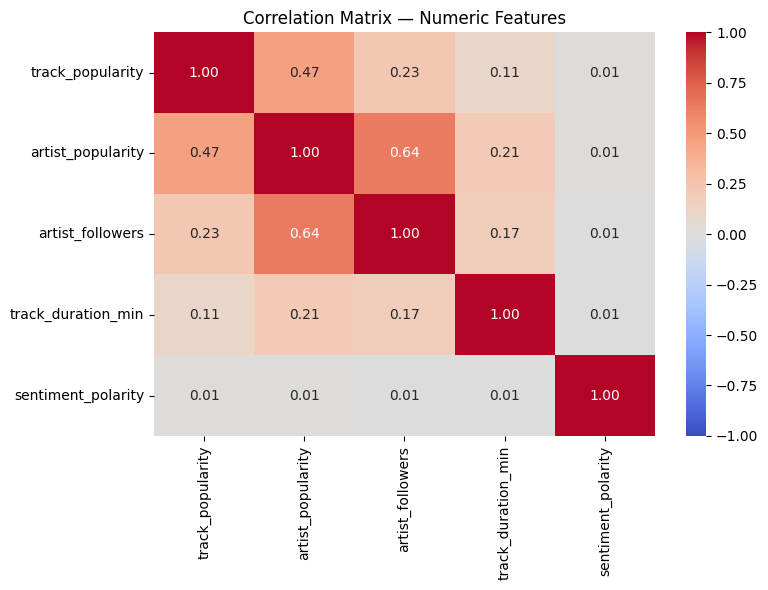

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['track_popularity', 'artist_popularity', 'artist_followers',
             'track_duration_min', 'sentiment_polarity']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

**HYPOTHESIS TESTING**

In [ ]:
explicit_pop = df[df['explicit'] == True]['track_popularity']
non_explicit_pop = df[df['explicit'] == False]['track_popularity']

t_stat, p_val = stats.ttest_ind(explicit_pop, non_explicit_pop, equal_var=False)
print(f"Explicit mean: {explicit_pop.mean():.2f}, Non-explicit mean: {non_explicit_pop.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.2e}")

Explicit mean: 57.82, Non-explicit mean: 50.53
t-statistic: 12.866, p-value: 3.87e-37


**One-way ANOVA — Does popularity differ across album types?**

In [ ]:
album_groups = [group['track_popularity'].values for name, group in df.groupby('album_type')]
f_stat, p_val_anova = stats.f_oneway(*album_groups)

print(df.groupby('album_type')['track_popularity'].mean())
print(f"\nF-statistic: {f_stat:.3f}, p-value: {p_val_anova:.2e}")

album_type
album          55.653459
compilation    40.512821
single         46.354082
Name: track_popularity, dtype: float64

F-statistic: 197.859, p-value: 9.88e-85


**Chi-square — Is explicit content associated with album type?**

In [ ]:
contingency = pd.crosstab(df['explicit'], df['album_type'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)

print(contingency)
print(f"\nChi2: {chi2:.3f}, p-value: {p_val_chi:.2e}, degrees of freedom: {dof}")

album_type  album  compilation  single
explicit                              
False        4315          470    1647
True         1540           37     570

Chi2: 90.561, p-value: 2.16e-20, degrees of freedom: 2


### **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("spotify_data_fully_cleaned.csv")
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['release_year'] = df['album_release_date'].dt.year

**DESCRIPTIVE STATISTICS**

In [ ]:
numeric_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']

desc_stats = df[numeric_cols].describe().T
desc_stats['skew'] = df[numeric_cols].skew()
desc_stats['median'] = df[numeric_cols].median()
print(desc_stats)

                     count          mean           std   min        25%  \
track_popularity    8579.0  5.235552e+01  2.381803e+01  0.00      39.00   
artist_popularity   8579.0  6.975440e+01  1.960608e+01  0.00      60.00   
artist_followers    8579.0  2.404312e+07  3.803580e+07  0.00  465340.50   
track_duration_min  8579.0  3.492803e+00  1.058084e+00  0.07       2.88   

                           50%          75%           max      skew  \
track_popularity         58.00        71.00  9.900000e+01 -0.784793   
artist_popularity        74.00        84.00  1.000000e+02 -1.033984   
artist_followers    6111369.00  27288825.00  1.455421e+08  1.960635   
track_duration_min        3.44         3.99  1.351000e+01  1.284737   

                        median  
track_popularity         58.00  
artist_popularity        74.00  
artist_followers    6111369.00  
track_duration_min        3.44  


**UNIVARIATE DISTRIBUTIONS**

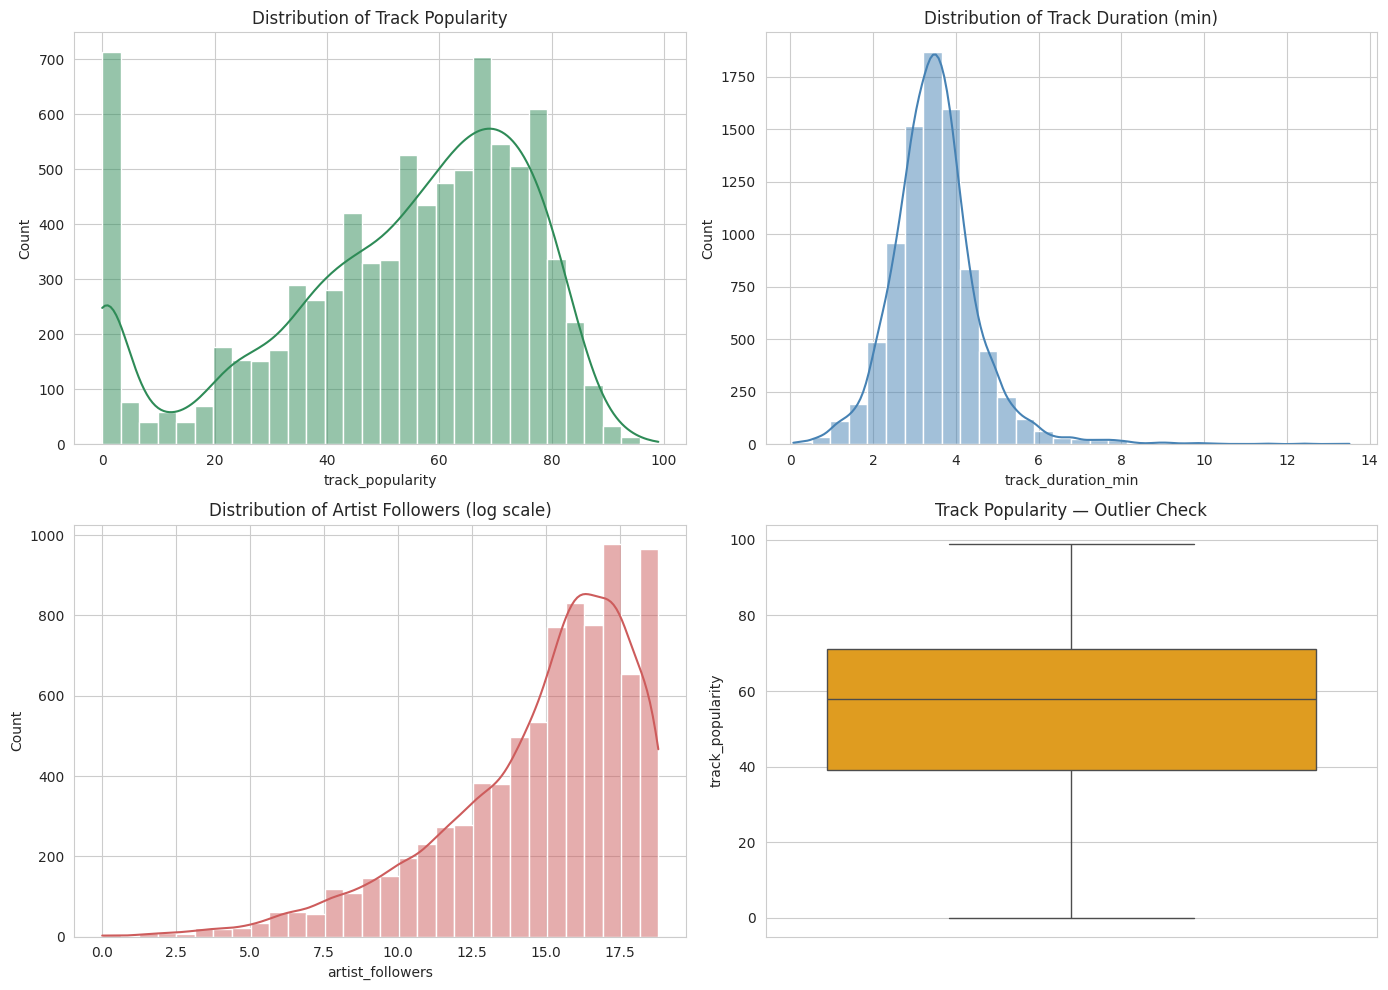

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['track_popularity'], bins=30, kde=True, ax=axes[0,0], color='seagreen')
axes[0,0].set_title('Distribution of Track Popularity')

sns.histplot(df['track_duration_min'], bins=30, kde=True, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Distribution of Track Duration (min)')

sns.histplot(np.log1p(df['artist_followers']), bins=30, kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Distribution of Artist Followers (log scale)')

sns.boxplot(y=df['track_popularity'], ax=axes[1,1], color='orange')
axes[1,1].set_title('Track Popularity — Outlier Check')

plt.tight_layout()
plt.show()

**CATEGORICAL COMPOSTION**

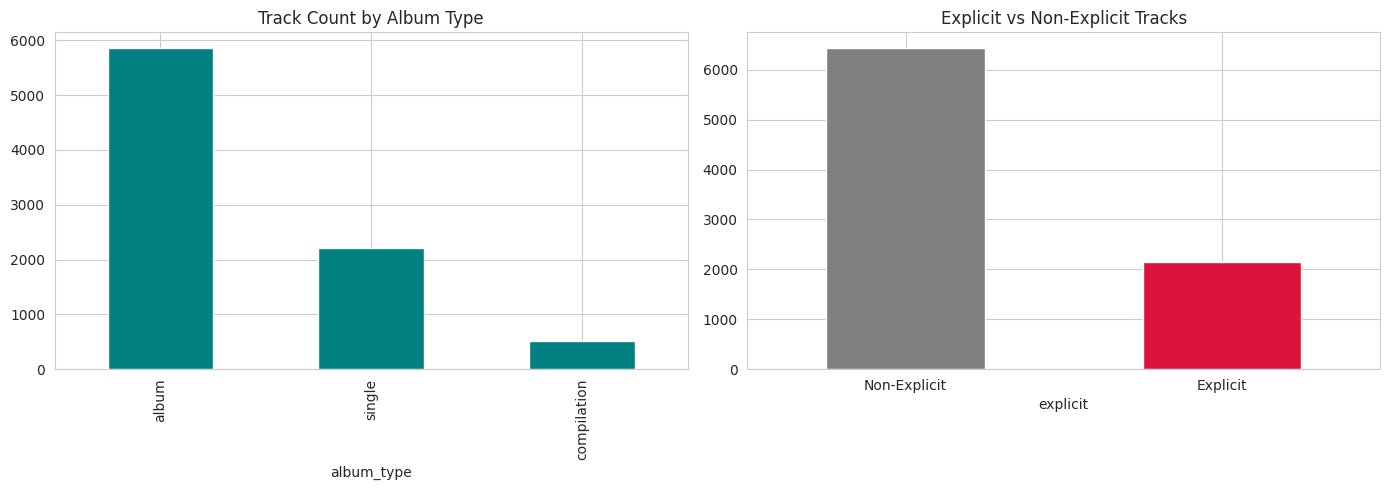

Explicit content share: 25.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['album_type'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Track Count by Album Type')

df['explicit'].value_counts().plot(kind='bar', ax=axes[1], color=['grey', 'crimson'])
axes[1].set_title('Explicit vs Non-Explicit Tracks')
axes[1].set_xticklabels(['Non-Explicit', 'Explicit'], rotation=0)

plt.tight_layout()
plt.show()

print(f"Explicit content share: {df['explicit'].mean()*100:.1f}%")

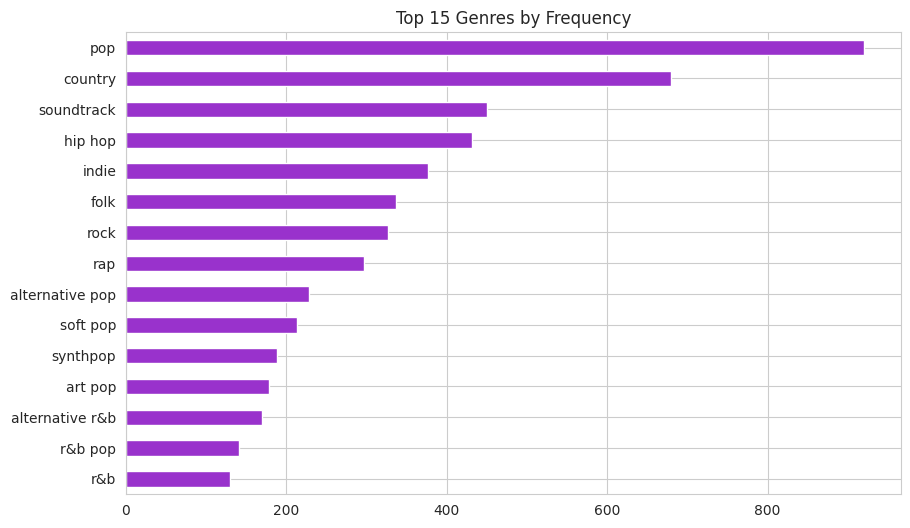

In [ ]:
genre_list = df['artist_genres'].replace('Unknown', np.nan).dropna().str.split(', ').sum()
top_genres = pd.Series(Counter(genre_list)).sort_values(ascending=False).head(15)

top_genres.plot(kind='barh', color='darkorchid', figsize=(10,6))
plt.title('Top 15 Genres by Frequency')
plt.gca().invert_yaxis()
plt.show()

### **BIVARIATE RELATIONSHIPS**

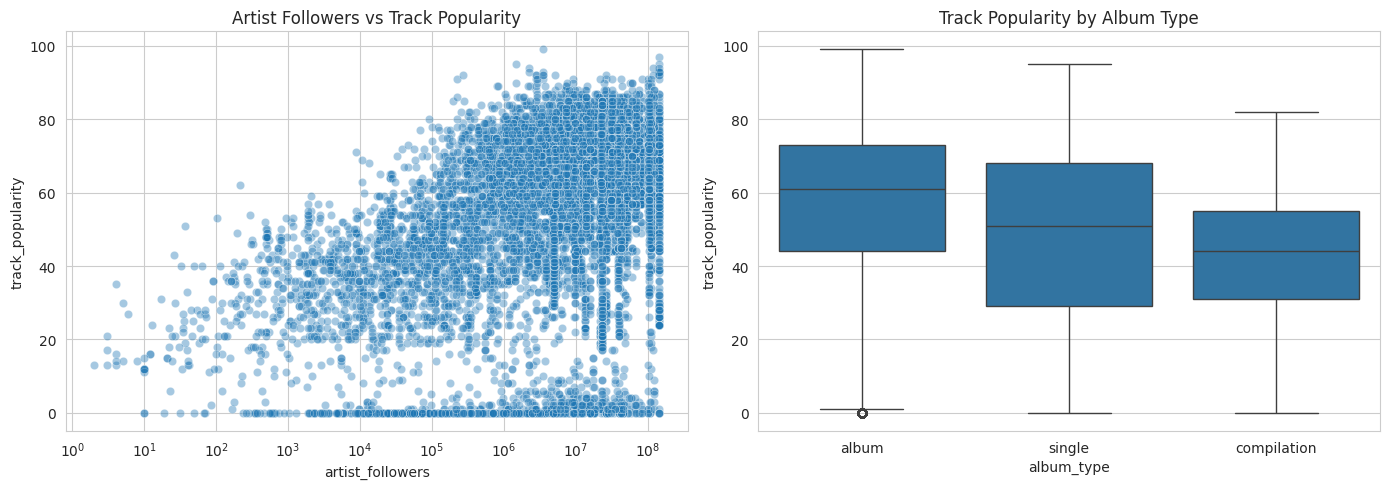

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df, x='artist_followers', y='track_popularity', alpha=0.4, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Artist Followers vs Track Popularity')

sns.boxplot(data=df, x='album_type', y='track_popularity', ax=axes[1])
axes[1].set_title('Track Popularity by Album Type')

plt.tight_layout()
plt.show()

**TIME BASED TRENDS**

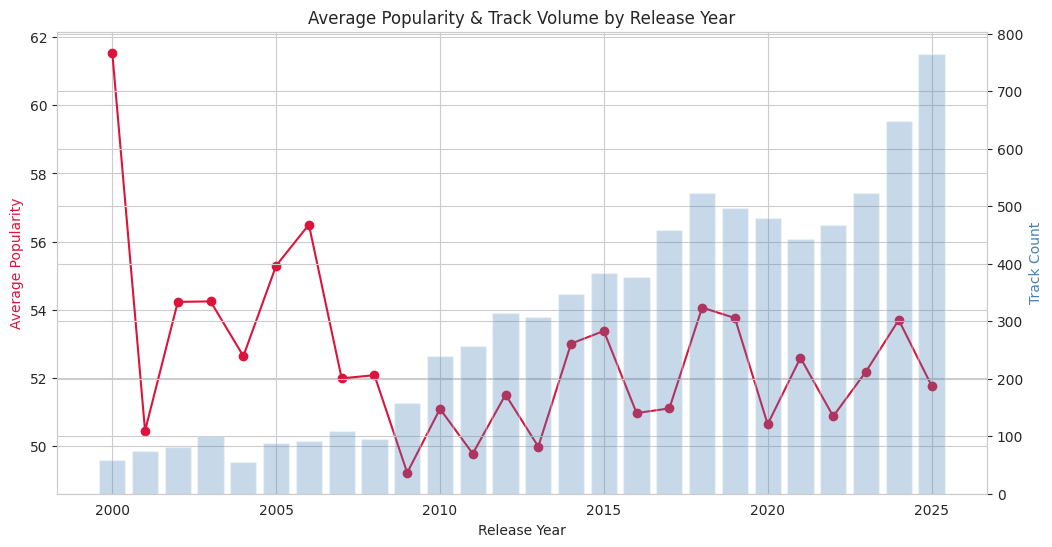

In [ ]:
yearly = df.groupby('release_year').agg(
    avg_popularity=('track_popularity', 'mean'),
    track_count=('track_id', 'count')
).reset_index()
yearly = yearly[yearly['release_year'] >= 2000]

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(yearly['release_year'], yearly['avg_popularity'], color='crimson', marker='o')
ax1.set_ylabel('Average Popularity', color='crimson')
ax1.set_xlabel('Release Year')

ax2 = ax1.twinx()
ax2.bar(yearly['release_year'], yearly['track_count'], alpha=0.3, color='steelblue')
ax2.set_ylabel('Track Count', color='steelblue')

plt.title('Average Popularity & Track Volume by Release Year')
plt.show()

**CONSOLIDATED KPI SUMMARY**

                        KPI  Value
               Total Tracks   8579
       Total Unique Artists   2547
       Avg Track Popularity  52.36
      Avg Artist Popularity  69.75
   Avg Track Duration (min)   3.49
 Explicit Content Share (%)   25.0
     Most Common Album Type  album
Repeat-Release Rows Flagged   1237
 Zero-Follower Rows Flagged      5


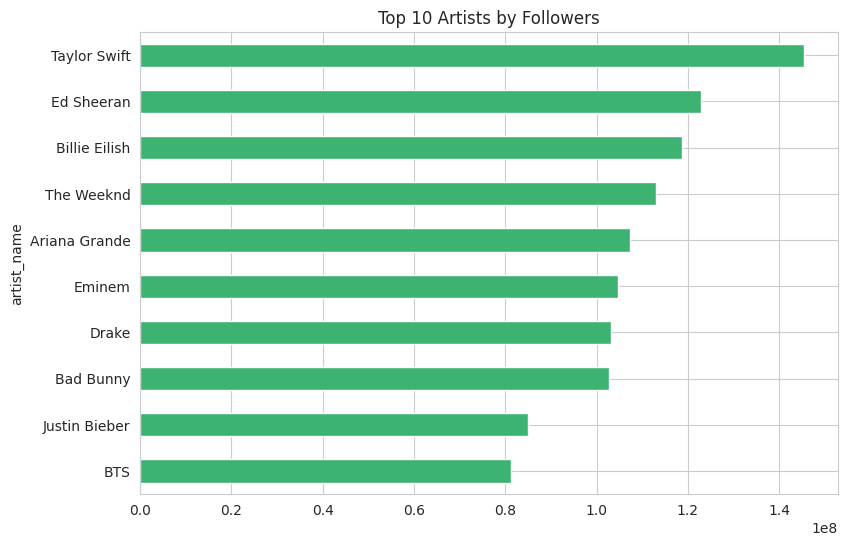

In [ ]:
kpis = {
    "Total Tracks": len(df),
    "Total Unique Artists": df['artist_name'].nunique(),
    "Avg Track Popularity": round(df['track_popularity'].mean(), 2),
    "Avg Artist Popularity": round(df['artist_popularity'].mean(), 2),
    "Avg Track Duration (min)": round(df['track_duration_min'].mean(), 2),
    "Explicit Content Share (%)": round(df['explicit'].mean()*100, 1),
    "Most Common Album Type": df['album_type'].mode()[0],
    "Repeat-Release Rows Flagged": int(df['is_track_repeat'].sum()),
    "Zero-Follower Rows Flagged": int(df['followers_missing_flag'].sum()),
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
print(kpi_df.to_string(index=False))

top_artists = df.groupby('artist_name')['artist_followers'].max().sort_values(ascending=False).head(10)
top_artists.plot(kind='barh', color='mediumseagreen', figsize=(9,6))
plt.title('Top 10 Artists by Followers')
plt.gca().invert_yaxis()
plt.show()